# Introduction to Variational Inference
## Inference as Optimization — and Its Limits


**PRPRO Guest Lecture** | IT University of Copenhagen

*Instructor: **Ola**, Postdoc in [SQUARE](https://square.itu.dk/)*

**Readings:**
- Blei, Kucukelbir, McAuliffe (2017). *Variational Inference: A Review for Statisticians*
- Kucukelbir et al. (2017). *Automatic Differentiation Variational Inference*
- Liu & Wang (2016). *Stein Variational Gradient Descent*

In [1]:
import numpy as np
import arviz as az
import pymc as pm
from scipy.stats import chi2
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from matplotlib.lines import Line2D
import pandas as pd
from scipy import stats
from scipy.stats import gaussian_kde
from pymc.variational.updates import adam
from notebook_utils import (
    rosenbrock_logp,
    two_beans_logp,
    rosenbrock_logp_pt,
    two_beans_logp_pt,
)
import pytensor
from svgd_demo import run_svgd, svgd_forces, median_bandwidth
from svgd_demo.visualize import animate_particles


plt.rcParams["figure.autolayout"] = True
az.style.use("arviz-darkgrid")

/home/pardo/repos/2026-prpro-spring/.venv/lib/python3.14/site-packages/arviz/__init__.py:39: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


<br/><br/><br/><br/><br/><br/><br/><br/><br/><br/>

# Recap: The Inference Problem

In Lecture 7, we saw that MCMC provides **asymptotically exact** samples from the posterior:

$$p(\theta \mid \mathcal{D}) = \frac{p(\mathcal{D} \mid \theta)\,p(\theta)}{\int p(\mathcal{D} \mid \theta)\,p(\theta)\, d\theta}$$

The denominator — the **marginal likelihood** (or evidence) — is an integral over the full parameter space. In all but the simplest models it has no closed form.
*Notice, it depends on the prior!*

**MCMC's contract:** "Give me enough time and I will give you unbiased samples."

# Notation
- Observed (data): $\mathcal{D} = \{(x,y)\}_{i=1}^n$ or $\mathcal{D} = \{x\}_{i=1}^n$.

  - There are $n$ data points, they are assumed [i.i.d](https://ericmjl.github.io/blog/2019/5/29/reasoning-about-shapes-and-probability-distributions/) samples from $p(\mathcal{D})$.
  - $p(\mathcal{D})$ is assumed to be unknown, but fixed.

**OBS**: Bayesians have terrible notation habits. Marginal likelihood also denoted $p(\mathcal{D})$, but is not the same. It depends on the choice of prior.

- Data point: $x\in \mathbb{R}^d$ and $y \in \mathbb{R}$ or $y \in Y$ with $|Y| < \infty$.

- Latent (unobserved) variables collected in: $\theta$.

- Posterior: $p(\theta \mid \mathcal{D})$  belief about $\theta$ having measured (and considered) $\mathcal{D}$.

- Prior: $p(\theta)$ belief about $\theta$ before measurements.

- Variational distribution (aka. guide), $q(\theta)$: distribution simplification of the posterior.

- Divergence measure $D(q,p)$, distributional "distance" between $q$ and $p$.

- Dirac delta function $\delta_{x^*}(x)$, $\int dx \left[\delta_{x^*}(x)\right] = 1$ and $\int dx \left[\delta_{x^*}(x)f(x)\right] = f(x^*)$ (assuming $x \in Dom(f)$).

<br/><br/><br/><br/><br/><br/><br/><br/><br/><br/>

## **Today:**

    We accept some approximation error to reduce computational cost or to scale to more complex models that would otherwise be intractable.


**Approach**: Reformulate inference as an optimization problem.

We will look at three variational inference algorithms:

1. *Maximum a posteriori* (**MAP**) estimation
2. *Automatic Differentiation Variational Inference* (**ADVI**)
3. *Stein Variational Gradient Descent* (**SVGD**) *[optional]*

**Why these?** They represent the three major forms of variational inference (and they are in PyMC).
- Point estimation.
- Distribution simplification.
- Fixed number of samples (this approach is relatively new).

All three are "blackbox methods" which allows us to automatically construct guides without user intervention.
### Geometric perspective
Each VI method uses a different objective and subspace which results in different "projections" of the posterior.
The objective is the expression we minimize, while the subspace defines the possible minimizers.

**Key takeaway from today**: An inference method that cannot represent a posterior feature, cannot find it. *This is a structural limitation, not a convergence failure.*

Output()

/home/pardo/repos/2026-prpro-spring/.venv/lib/python3.14/site-packages/pytensor/link/c/cmodule.py:2986: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(
Finished [100%]: Average Loss = 0.96377
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


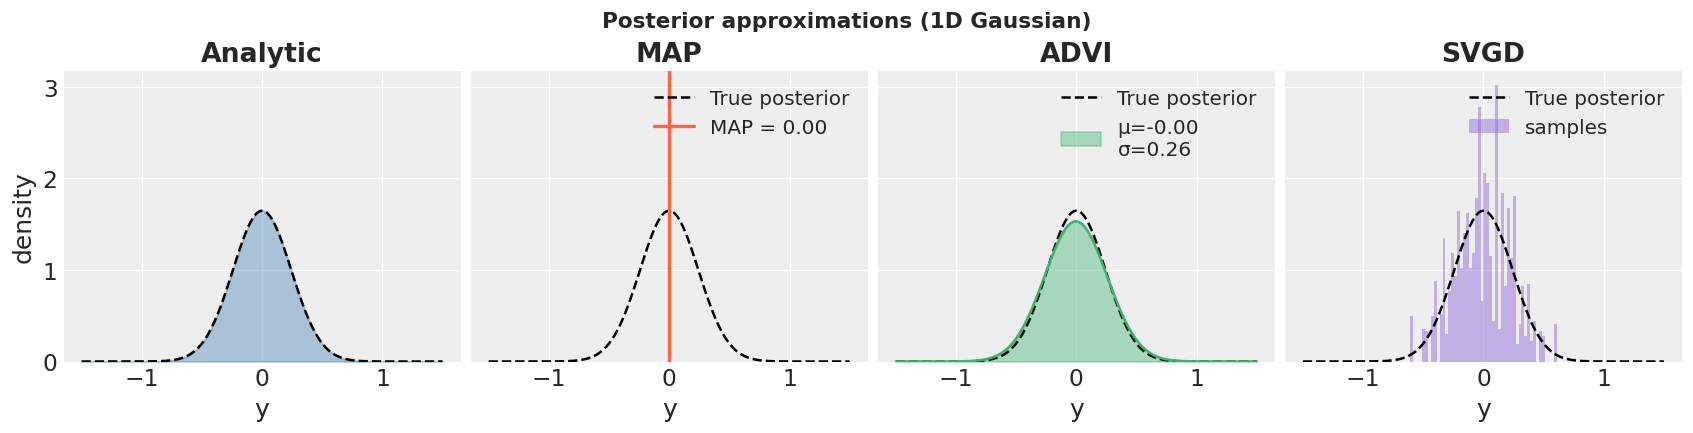

In [2]:
# --- 1D setup ---
mu = 0.0
sigma_prior = 1.0
sig = 0.25
x_obs = 0.0

# analytic posterior
s2 = 1 / (1/sigma_prior**2 + 1/sig**2)
m  = s2 * (mu/sigma_prior**2 + x_obs/sig**2)
xg = np.linspace(-1.5, 1.5, 300)
post_pdf = stats.norm.pdf(xg, m, np.sqrt(s2))

with pm.Model() as model:
    y  = pm.Normal("y", mu=mu, sigma=sigma_prior)
    pm.Normal("x", mu=y, sigma=sig, observed=x_obs)

    mp   = pm.find_MAP()
    advi = pm.fit(5000, method="advi", progressbar=False,
                  obj_optimizer=adam(learning_rate=0.001))
    svgd_fit = pm.fit(5000, method="svgd", progressbar=False,
                      obj_optimizer=adam(learning_rate=0.001))
    sv = svgd_fit.sample(1500).posterior["y"].values.ravel()

advi_mean = advi.mean.eval()[0]
advi_std  = advi.std.eval()[0]
advi_pdf  = stats.norm.pdf(xg, advi_mean, advi_std)

# --- Plot ---
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5), sharey=True,
                         dpi=120, constrained_layout=True)
titles = ["Analytic", "MAP", "ADVI", "SVGD"]
colors = ["steelblue", "tomato", "mediumseagreen", "mediumpurple"]

for ax, title, color in zip(axes, titles, colors):
    ax.plot(xg, post_pdf, "k--", lw=1.5, label="True posterior")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("y")

# Analytic
axes[0].fill_between(xg, post_pdf, alpha=0.4, color=colors[0])
axes[0].set_ylabel("density")

# MAP
axes[1].axvline(mp["y"], color=colors[1], lw=2, label=f"MAP = {mp['y']:.2f}")
axes[1].legend(fontsize=12)

# ADVI
axes[2].fill_between(xg, advi_pdf, alpha=0.4, color=colors[2],
                     label=f"μ={advi_mean:.2f}\nσ={advi_std:.2f}")
axes[2].plot(xg, advi_pdf, color=colors[2], lw=1.5)
axes[2].legend(fontsize=12)

# SVGD
axes[3].hist(sv, bins=50, density=True, alpha=0.5, color=colors[3], label="samples")
axes[3].legend(fontsize=12)

fig.suptitle("Posterior approximations (1D Gaussian)", fontsize=13, fontweight="bold");

<br/><br/><br/><br/><br/><br/><br/><br/><br/><br/>

# Inference as Optimization

**Core idea**: Instead of *sampling* from the posterior $p(\theta \mid \mathcal{D})$, we *search* for the best approximation $q^*$ within a **tractable** family $\mathcal{Q}$.

$$q^* = \arg\min_{q \in \mathcal{Q}} \; D(q, p(\theta \mid \mathcal{D}))$$

Here $D$ is some divergence measure (typically KL divergence).

## The Subspace Constraint

What makes $\mathcal{Q}$ tractable? The family $\mathcal{Q}$ is a **parameterized subspace** of all probability distributions.

Each choice of $\mathcal{Q}$ defines what the approximation *can* represent:

| Family $\mathcal{Q}$ | Method | Parameterization | What it can capture |
|----------------------|--------|------------------|---------------------|
| Point masses $\{\delta_{\theta^*}\}$ | MAP| $\theta^* \in \mathbb{R}^d$ | Mode only |
| Factorized Gaussians | ADVI |$\mu_i, \sigma_i$ for each dim | Marginal means/variances |
| Full-rank Gaussian | ADVI | $\mu, \Sigma$ | First two moments |
| Particle ensemble | SVGD | $\{\theta_i\}_{i=1}^n$ | Empirical distribution |

**Key insight:** Minimizing the divergence *projects* the true posterior onto $\mathcal{Q}$. Features of $p(\theta \mid \mathcal{D})$ that lie outside $\mathcal{Q}$ are lost.
No amount of optimization can recover them.

<br/><br/><br/><br/><br/><br/><br/><br/><br/><br/>

# The KL Divergence

The **Kullback–Leibler divergence** from distribution $q$ to distribution $p$ is

$$\mathrm{KL}(q \,\|\, p)
  = \int q(\theta)\,\log \frac{q(\theta)}{p(\theta)}\, d\theta
  = \mathbb{E}_{q}\!\left[\log \frac{q(\theta)}{p(\theta)}\right].$$

Requirement: $q \ll p$

**Properties**:

| Property | Implication |
|----------|-------------|
| $\mathrm{KL}(q \,\|\, p) \geq 0$ | Non-negativity (Gibbs' inequality) |
| $\mathrm{KL}(q \,\|\, p) = 0 \iff q = p$ | Zero iff distributions match a.e.|
| $\mathrm{KL}(q \,\|\, p) \neq \mathrm{KL}(p \,\|\, q)$ | **Not symmetric** — direction matters! |

## Forward vs. Reverse KL

### Reverse KL (ADVI uses this implicitly)
$$\mathrm{KL}(q \,\|\, p)
  = \mathbb{E}_{q}\!\left[\log \frac{q(\theta)}{p(\theta | \mathcal{D})}\right]$$

Minimizing this over $q$ penalises $q(\theta) > 0$ in regions where $p(\theta | \mathcal{D}) \approx 0$.
**Result**: $q$ is **mode-seeking** — it locks onto a single mode and underestimates variance.

*Laplace approximation uses this explicitly.*

### Forward KL
$$\mathrm{KL}(p \,\|\, q)
  = \mathbb{E}_{p}\!\left[\log \frac{p(\theta | \mathcal{D})}{q(\theta)}\right]$$

Minimizing this over $q$ penalises $q(\theta) \approx 0$ in regions where $p(\theta|\mathcal{D}) > 0$.
**Result**: $q$ is **mass-covering** — it tries to cover all of $p$, often overestimating variance.

**Question**: What is the problem with optimizing forward KL?

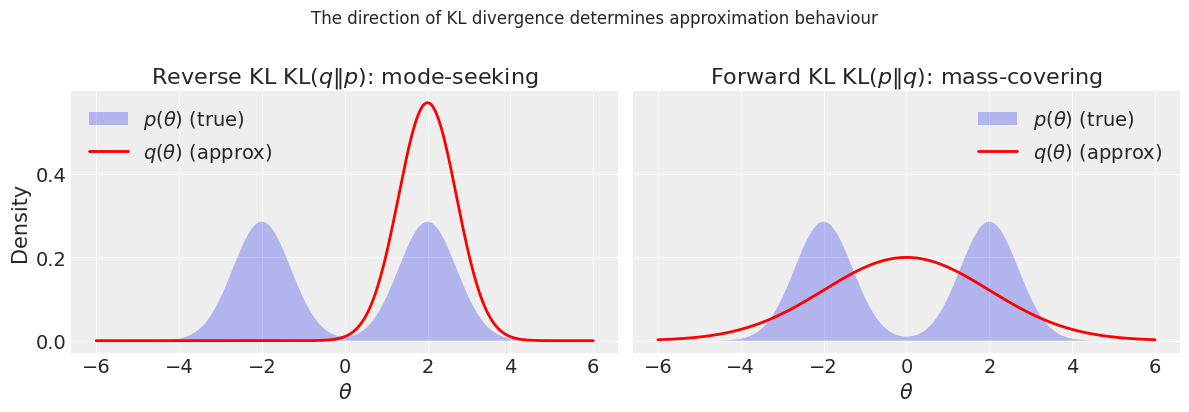

In [3]:

x = np.linspace(-6, 6, 500)
p = 0.5 * stats.norm.pdf(x, -2, 0.7) + 0.5 * stats.norm.pdf(x, 2, 0.7)

q_reverse = stats.norm.pdf(x, 2, 0.7)
q_forward = stats.norm.pdf(x, 0, 2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, q, title in zip(axes,
                          [q_reverse, q_forward],
                          [r'Reverse KL $\mathrm{KL}(q\|p)$: mode-seeking',
                           r'Forward KL $\mathrm{KL}(p\|q)$: mass-covering']):
    ax.fill_between(x, p, alpha=0.3, label=r'$p(\theta)$ (true)')
    ax.plot(x, q, 'r-', lw=2, label=r'$q(\theta)$ (approx)')
    ax.set_xlabel(r'$\theta$')
    ax.set_title(title)
    ax.legend()

axes[0].set_ylabel('Density')
fig.suptitle('The direction of KL divergence determines approximation behaviour', y=1.02)
plt.tight_layout()

<br/><br/><br/><br/><br/><br/><br/><br/><br/><br/>

# MAP Estimation

## MAP as Degenerate Variational Inference

MAP estimation finds the posterior mode:

$$\theta_{\text{MAP}} = \arg\max_\theta \; \log p(\theta, \mathcal{D})
= \arg\max_\theta \; \bigl[\log p(\mathcal{D} \mid \theta) + \log p(\theta)\bigr] = \arg\max_\theta \; \bigl[\log p(\mathcal{D} \mid \theta) + \log p(\theta) + \text{const}\bigr]$$

This is equivalent to minimising $\mathrm{KL}(q \| p(\theta \mid \mathcal{D}))$ when $\mathcal{Q} = \{\delta_{\theta^*}\}$:

$$\mathrm{KL}\bigl(\delta_{\theta^*} \,\big\|\, p(\theta \mid \mathcal{D})\bigr)
= -\log p(\mathcal{D} \mid \theta^*) - \log p(\theta^*) + \text{const}$$

**Question**: What is the constant here?

*So MAP is VI with the most restrictive possible family. It discards **all** uncertainty information.*

<br/><br/><br/><br/><br/><br/><br/><br/><br/><br/>

In [4]:
data = [1]*14 + [0]*6

# Setup conjugate model. Great for testing, not so much modeling! There are a bunch: https://en.wikipedia.org/wiki/Conjugate_prior
with pm.Model() as map_model:
    θ = pm.Beta('θ', alpha=1, beta=1)
    y = pm.Bernoulli('y', p=θ, observed=data)
    map_estimate = pm.find_MAP()

print(f"MAP estimate: θ = {map_estimate['θ']:.2f}")
print(f"Analytical mode: θ = {14/20:.2f}");

Output()

MAP estimate: θ = 0.70
Analytical mode: θ = 0.70


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [θ]
Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 11 seconds.


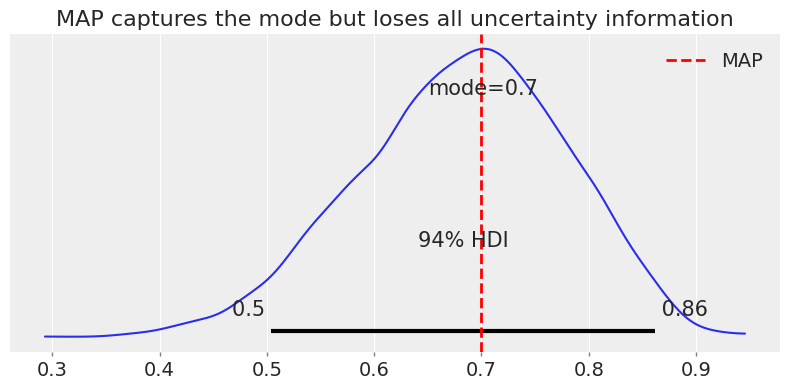

In [5]:
with map_model:
    trace = pm.sample(2000, return_inferencedata=True, progressbar=False)

fig, ax = plt.subplots(figsize=(8, 4))
az.plot_posterior(trace, var_names=['θ'], point_estimate='mode', ax=ax)
ax.axvline(map_estimate['θ'], color='red', linestyle='--', linewidth=2, label='MAP')
ax.legend()
ax.set_title("MAP captures the mode but loses all uncertainty information");

<br/><br/><br/><br/><br/><br/><br/><br/><br/><br/>

# ADVI: Automatic Differentiation Variational Inference

We want to minimise $\mathrm{KL}(q_\phi(\theta) \,\|\, p(\theta \mid \mathcal{D}))$ by choosing $\phi$, but the posterior $p(\theta \mid \mathcal{D})$ is intractable.

## Solution: Optimize the Evidence Lower Bound (ELBO)

 Expand the KL:

$$
\mathrm{KL}\bigl(q_\phi(\theta) \,\big\|\, p(\theta \mid \mathcal{D})\bigr)
= \mathbb{E}_{q_\phi}\!\left[\log q_\phi(\theta) - \log p(\theta \mid \mathcal{D})\right]
$$

Substitute $p(\theta \mid \mathcal{D}) = p(\mathcal{D}, \theta) / p(\mathcal{D})$:

$$
= \mathbb{E}_{q_\phi}\!\left[\log q_\phi(\theta) - \log p(\mathcal{D}, \theta)\right] + \log p(\mathcal{D})
$$

Rearranging:

$$
\log p(\mathcal{D})
= \underbrace{\mathbb{E}_{q_\phi}\!\left[\log p(\mathcal{D}, \theta) - \log q_\phi(\theta)\right]}_{\displaystyle\text{ELBO}(\phi)}
\;+\;
\mathrm{KL}\bigl(q_\phi(\theta) \,\big\|\, p(\theta \mid \mathcal{D})\bigr)
$$

Since $\mathrm{KL} \geq 0$:

$$
\boxed{\log p(\mathcal{D}) \;\geq\; \text{ELBO}(\phi)
= \mathbb{E}_{q_\phi}\!\left[\log p(\mathcal{D}, \theta) - \log q_\phi(\theta)\right]}
$$


<br/><br/><br/><br/><br/><br/><br/><br/><br/><br/>

## Interpretations of the ELBO

$$
\text{ELBO}(\phi)
= \underbrace{\mathbb{E}_{q_\phi}\!\left[\log p(\mathcal{D} \mid \theta)\right]}_{\text{expected log-likelihood}}
\;-\;
\underbrace{\mathrm{KL}\bigl(q_\phi(\theta) \,\big\|\, p(\theta)\bigr)}_{\text{complexity penalty}}
$$

Maximising the ELBO simultaneously pushes $q_\phi$ to explain the data well and to stay close to the prior.

$$
\text{ELBO}(\phi)
= \underbrace{\mathbb{E}_{q_\phi}\!\left[\log p(\mathcal{D}, \theta)\right]}_{\text{expected joint}}
\;-\;
\underbrace{\mathbb{E}_{q_\phi} [\log q_\phi(\theta)]}_{\text{entropy penalty}}
$$

Maximising the ELBO pushes $q_\phi$ to explain the model with the highest entropy (i.e. least informative) approximation.

<br/><br/><br/><br/><br/><br/><br/><br/><br/><br/>


## The Reparameterization Trick (for Gaussians)

Assume the guide is a normal distribution, then ELBO gradient w.r.t. variational parameters $\phi = (\mu, \sigma)$ is

$$\nabla_\phi \,\text{ELBO}(\phi)
= \nabla_\phi \,\mathbb{E}_{q_\phi(\theta)}\!\bigl[f(\theta)\bigr]$$

**Problem:** The expectation is over $q_\phi$, which depends on $\phi$. Naïve Monte Carlo estimation (score-function estimator) has high variance.

**Solution — Reparameterize:** Write $\theta = g(\phi, \varepsilon)$ where $\varepsilon \sim p(\varepsilon)$ does not depend on $\phi$.

For Gaussian $q_\phi = \mathcal{N}(\mu, \text{diag}(\sigma^2))$:

$$\theta = \mu + \sigma \odot \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, I)$$

*There is a bunch of these: [Random variates in one line of code](https://luc.devroye.org/onelineofcode.pdf).*

Now the gradient moves inside the expectation:

$$\nabla_\phi \,\text{ELBO}(\phi)
= \mathbb{E}_{\varepsilon \sim \mathcal{N}(0,I)}\!\bigl[\nabla_\phi \,f\bigl(g(\phi, \varepsilon)\bigr)\bigr]
\approx \frac{1}{M}\sum_{m=1}^{M} \nabla_\phi \,f\bigl(g(\phi, \varepsilon^{(m)})\bigr)$$

This is **pathwise gradient estimation**. It has much lower variance than the score-function (REINFORCE) estimator, enabling practical stochastic optimisation of the ELBO.

**Why is reparameterization necessary?**

The core problem is that we need to differentiate an expectation where the distribution itself depends on the parameters:

$$\nabla_\phi \,\mathbb{E}_{q_\phi(\theta)}\!\bigl[f(\theta)\bigr] = \nabla_\phi \int q_\phi(\theta) f(\theta) \, d\theta$$

We cannot simply exchange $\nabla_\phi$ and $\int$ because the variable of integration $\theta$ depends on $\phi$ through $q_\phi$. The reparameterization $\theta = g(\phi, \varepsilon)$ performs a change of variables that makes $\varepsilon$ the integration variable, which is independent of $\phi$.

# **Automatic** ... VI
The reparameterization makes gradient computation automatic (with AD), so the remaining automation challenge:

    ADVI approximates every random variable with a Gaussian, but not all distributions have support on the reals.

**Solution**: Variable transformations and change of variables (will turn up in SVGD again).

    This is a core principle for making deep PPLs

## Example

$\sigma \sim \text{Exponential}(\lambda)$ has support $\sigma \in \mathbb{R}^+$.

 1. **Transform:** $\eta = \log(\sigma) \in \mathbb{R}$. Now ADVI fits $q_\phi(\eta) = \mathcal{N}(\mu, s^2)$.

 2.  **Correct the density:**

        $$p_\eta(\eta) = p_\sigma(\underbrace{e^\eta}_{\sigma}) \cdot \underbrace{\left|\frac{d\sigma}{d\eta}\right|}_{\text{Jacobian}} = \lambda e^{-\lambda e^\eta} \cdot e^\eta$$

The Jacobian accounts for how the transformation stretches or compresses local volume
([3Blue1Brown: The Determinant](https://www.youtube.com/watch?v=Ip3X9LOh2dk)).
In higher dimensions this becomes $|\det J|$.

 3. **Optimize in $\eta$-space, report in $\sigma$-space.** The user never sees $\eta$.

<br/><br/><br/><br/><br/><br/><br/><br/><br/><br/>

## Two versions of ADVI

### Mean-Field ADVI

Mean-field ADVI assumes the variational distribution factorises across coordinates:

$$q_\phi(\theta) = \prod_{i=1}^{d} q_i(\theta_i)
= \prod_{i=1}^{d} \mathcal{N}(\theta_i \mid \mu_i, \sigma_i^2)$$

This means **all posterior correlations are set to zero by construction**. Even after perfect optimisation, *if the true posterior has $\text{Corr}(\theta_i, \theta_j) \neq 0$, mean-field ADVI will miss it*.

### Full-rank ADVI
Full-rank ADVI lifts this restriction:
$$q_\phi(\theta) = \mathcal{N}(\boldsymbol{\mu},\; L L^\top), \quad L \in \mathbb{R}^{d \times d} \text{ lower-triangular}$$

The Cholesky factor $L$ has $d(d{+}1)/2$ free parameters, allowing arbitrary Gaussian correlations.

Optimization is usually done with a log transformation on the diagonal. This move ensures the covariance stays positive definite.


### Complexity comparison

| | Parameters | Per-iteration cost | Memory |
|---|---|---|---|
| Mean-field | $2d$ | $O(d)$ | $O(d)$ |
| Full-rank | $d + d(d{+}1)/2$ | $O(d^2)$ | $O(d^2)$ |

### Warning about fullrank
Full-rank's richer approximation introduces $O(d^2)$ parameters, which demands narrow priors or lots of data. Prefer full-rank only when latents are highly correlated and $d(d+1)/2 \ll$ effective observation size. **Beyond ~300 latent dimensions, use mean-field.**

<br/><br/><br/><br/><br/><br/><br/><br/><br/><br/>

In [6]:
# Load terrain ruggedness / GDP dataset
rugged = pd.read_csv('Data/rugged.csv', sep=';')

# Drop countries with missing GDP data
rugged = rugged[rugged['rgdppc_2000'].notna()].copy()

# Log-transform GDP, then standardize (z-score) both GDP and ruggedness
rugged['log_gdp'] = np.log(rugged['rgdppc_2000'])
rugged['log_gdp_std'] = (rugged['log_gdp'] - rugged['log_gdp'].mean()) / rugged['log_gdp'].std()
rugged['rugged_std'] = (rugged['rugged'] - rugged['rugged'].mean()) / rugged['rugged'].std()

# Binary continent index: 1 = Africa, 0 = rest of world
rugged['cid'] = (rugged['cont_africa'] == 1).astype(int)

# Prediction grid spanning the observed ruggedness range
rugged_grid = np.linspace(rugged['rugged_std'].min(), rugged['rugged_std'].max(), 100)

# Bayesian linear regression: log_gdp_std ~ a[continent] + b[continent] * rugged_std
# Separate intercept and slope per continent captures Africa's reversed GDP–ruggedness effect
with pm.Model() as advi_model:
    a = pm.Normal('a', mu=0, sigma=1, shape=2)         # continent-specific intercepts
    b = pm.Normal('b', mu=0, sigma=0.5, shape=2)       # continent-specific slopes
    sigma = pm.Exponential('sigma', 1)                 # shared observation noise

    # Index into a/b by continent id to vectorize across all countries
    mu = a[rugged['cid'].values] + b[rugged['cid'].values] * rugged['rugged_std'].values
    y = pm.Normal('y', mu=mu, sigma=sigma, observed=rugged['log_gdp_std'].values)

    # Fit with two variational families using Adam optimizer:
    # Mean-field assumes independent posteriors; full-rank captures correlations
    approx_mf_adam = pm.fit(
        method='advi', n=2000, progressbar=False,
        obj_optimizer=adam(learning_rate=0.01), obj_n_mc=10,
    )
    approx_fr_adam = pm.fit(
        method='fullrank_advi', n=10000, progressbar=False,
        obj_optimizer=adam(learning_rate=0.01), obj_n_mc=20,  # more MC samples for stable covariance
    )

Finished [100%]: Average Loss = 215.64
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
Finished [100%]: Average Loss = 215.21


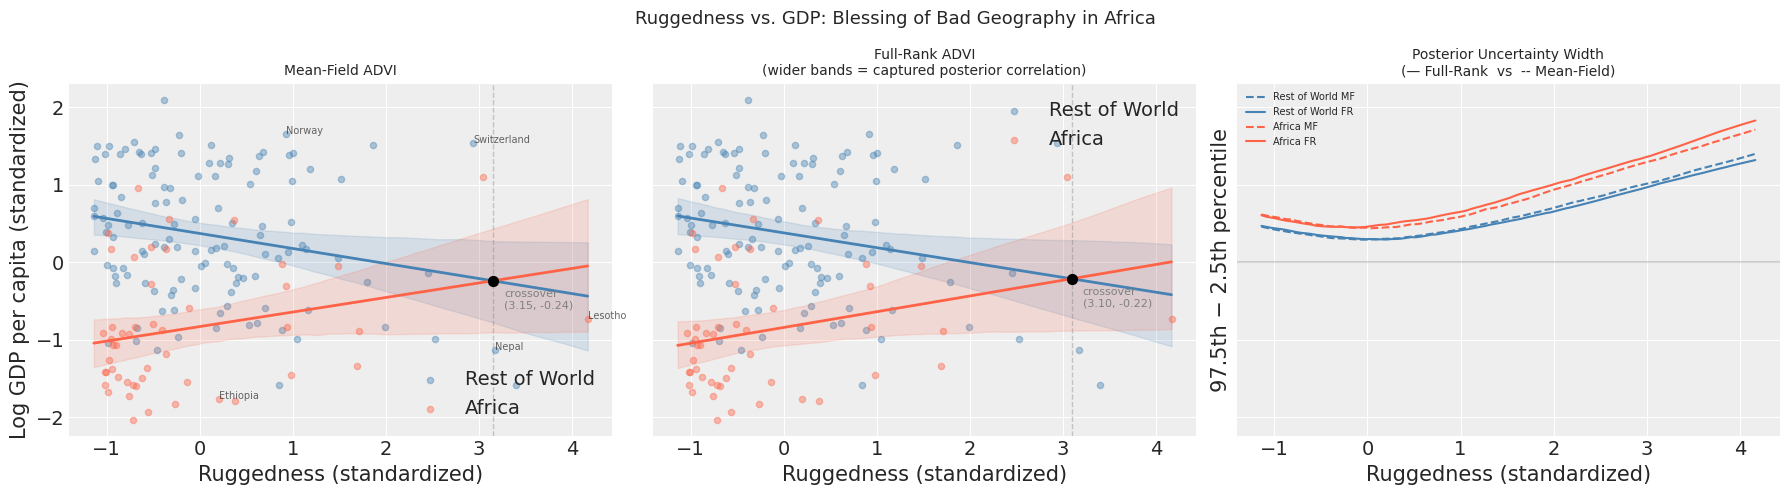

In [7]:
N_SAMPLES = 1_000
trace_mf = approx_mf_adam.sample(N_SAMPLES)
trace_fr = approx_fr_adam.sample(N_SAMPLES)
rugged_grid = np.linspace(rugged['rugged_std'].min(), rugged['rugged_std'].max(), 100)

def posterior_lines(trace, cid):
    """Compute posterior regression lines: a[cid] + b[cid] * x for each sample."""
    post = trace.posterior
    a = post['a'].values[0, :, cid, None]  # (n_samples, 1)
    b = post['b'].values[0, :, cid, None]  # (n_samples, 1)
    return a + b * rugged_grid               # (n_samples, 100)

def compute_band(lines):
    """Return mean line and 95% credible interval."""
    mean = lines.mean(axis=0)
    lo, hi = np.percentile(lines, [2.5, 97.5], axis=0)
    return mean, lo, hi

def find_crossover(lines_dict):
    """Find the ruggedness value where the two group-mean lines intersect."""
    mean0 = lines_dict[0].mean(axis=0)
    mean1 = lines_dict[1].mean(axis=0)
    idx = np.argmin(np.abs(mean0 - mean1))
    return rugged_grid[idx], mean0[idx]

CID_VALUES = [0, 1]
lines_mf = {cid: posterior_lines(trace_mf, cid) for cid in CID_VALUES}
lines_fr = {cid: posterior_lines(trace_fr, cid) for cid in CID_VALUES}
bands_mf = {cid: compute_band(lines_mf[cid]) for cid in CID_VALUES}
bands_fr = {cid: compute_band(lines_fr[cid]) for cid in CID_VALUES}
masks = {cid: rugged['cid'] == cid for cid in CID_VALUES}

AFRICA_COLOR, WORLD_COLOR = 'tomato', 'steelblue'
LABELS = {0: 'Rest of World', 1: 'Africa'}
COLORS = {0: WORLD_COLOR, 1: AFRICA_COLOR}
TITLES = {
    'Mean-Field ADVI': 'Mean-Field ADVI',
    'Full-Rank ADVI': 'Full-Rank ADVI\n(wider bands = captured posterior correlation)',
}
HIGHLIGHT_COUNTRIES = {'Nepal', 'Switzerland', 'Lesotho', 'Ethiopia', 'Norway'}
panel_specs = [
    ('Mean-Field ADVI', lines_mf, bands_mf),
    ('Full-Rank ADVI',  lines_fr, bands_fr),
]

fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, (label, lines_dict, bands_dict) in zip(axs[:2], panel_specs):
    for cid in CID_VALUES:
        mask = masks[cid]
        ax.scatter(
            rugged.loc[mask, 'rugged_std'],
            rugged.loc[mask, 'log_gdp_std'],
            color=COLORS[cid], alpha=0.4, s=20, label=LABELS[cid],
        )
        mean_line, lo, hi = bands_dict[cid]
        ax.plot(rugged_grid, mean_line, color=COLORS[cid], linewidth=2)
        ax.fill_between(rugged_grid, lo, hi, color=COLORS[cid], alpha=0.15)

    x_cross, y_cross = find_crossover(lines_dict)
    ax.axvline(x=x_cross, color='gray', ls='--', alpha=0.4, lw=1)
    ax.scatter([x_cross], [y_cross], color='black', zorder=5, s=50)
    ax.annotate(
        f'crossover\n({x_cross:.2f}, {y_cross:.2f})',
        (x_cross, y_cross),
        textcoords='offset points', xytext=(8, -20),
        fontsize=8, color='gray',
    )
    ax.set_title(TITLES[label], fontsize=10)
    ax.set_xlabel('Ruggedness (standardized)')
    ax.legend()

highlight_rows = rugged[rugged['country'].isin(HIGHLIGHT_COUNTRIES)]
for _, row in highlight_rows.iterrows():
    axs[0].annotate(
        row['country'],
        (row['rugged_std'], row['log_gdp_std']),
        fontsize=7, alpha=0.7,
    )
axs[0].set_ylabel('Log GDP per capita (standardized)')
axs[1].set_ylim(axs[0].get_ylim())

# Right panel: compare 95% posterior uncertainty widths
ax = axs[2]
for cid in CID_VALUES:
    _, lo_mf, hi_mf = bands_mf[cid]
    _, lo_fr, hi_fr = bands_fr[cid]
    ax.plot(rugged_grid, hi_mf - lo_mf, color=COLORS[cid], ls='--',
            label=f'{LABELS[cid]} MF')
    ax.plot(rugged_grid, hi_fr - lo_fr, color=COLORS[cid], ls='-',
            label=f'{LABELS[cid]} FR')

ax.axhline(0, color='gray', alpha=0.3)
ax.set_title('Posterior Uncertainty Width\n(— Full-Rank  vs  -- Mean-Field)', fontsize=10)
ax.set_xlabel('Ruggedness (standardized)')
ax.set_ylabel('97.5th − 2.5th percentile')
ax.legend(fontsize=7)

fig.suptitle('Ruggedness vs. GDP: Blessing of Bad Geography in Africa',
             fontsize=13)
plt.tight_layout()

<br/><br/><br/><br/><br/><br/><br/><br/><br/><br/>

## Scaling ADVI with Mini-Batches ([Tricky with HMC](https://proceedings.mlr.press/v37/betancourt15.pdf))

For large datasets, computing the full log-likelihood gradient is expensive. Mini-batching provides an unbiased gradient estimator that enables stochastic optimisation.

**Setup.** Given a dataset $\mathcal{D} = \{x_1, \ldots, x_n\}$, the full log-likelihood is:

$$\mathcal{L}(\theta) = \sum_{i=1}^{n} \log p(x_i \mid \theta) = \frac{n}{n} \sum_{i=1}^{n} \log p(x_i \mid \theta) \approx n \cdot \mathbb{E}_{x \sim \mathcal{D}}[\log p(x \mid \theta)]$$

**Mini-batch estimator.** Sample $m \ll n$ points uniformly from $\mathcal{D}$ and define:

$$\hat{\mathcal{L}}(\theta) = \frac{n}{m} \sum_{i=1}^{m} \log p(x_i \mid \theta)$$

**Unbiasedness.** The estimator $\hat{\mathcal{L}}(\theta)$ is unbiased for $\mathcal{L}(\theta)$:

$$\mathbb{E}_{x \sim \mathcal{D}}[\hat{\mathcal{L}}(\theta)] = \frac{n}{m} \cdot m \cdot \mathbb{E}_{x \sim \mathcal{D}}[\log p(x \mid \theta)] = \mathcal{L}(\theta)$$

The mini-batch gradient is an unbiased estimator of the full gradient.

In [8]:
n_obs = 25_000
np.random.seed(42)
x_data = np.random.randn(n_obs)

true_beta = 0.5
true_sigma = 0.3
y_data = true_beta * x_data +  true_sigma*np.random.randn(n_obs)

with pm.Model() as fullbatch_model:
    beta = pm.Normal("beta", mu=0, sigma=1)
    sigma = pm.HalfNormal("sigma", sigma=1)

    mu = beta * x_data
    likelihood = pm.Normal("y", mu=mu, sigma=sigma, observed=y_data, total_size=n_obs)

    approx = pm.fit(2_000, method='advi', obj_optimizer=adam(learning_rate=0.1), obj_n_mc=20,)


# Stack so one Minibatch call = aligned indices
data_2d = np.column_stack([x_data, y_data])  # (25_000, 2)

# Shared variables hold the full data for the model graph
shared_x = pytensor.shared(x_data, name="x")
shared_y = pytensor.shared(y_data, name="y")

# Single minibatch tensor — same row indices for both columns
data_mb = pm.Minibatch(data_2d, batch_size=1_000)

with pm.Model() as minibatch_model:
    beta  = pm.Normal("beta", mu=0, sigma=1)
    sigma = pm.HalfNormal("sigma", sigma=1)
    mu    = beta * shared_x
    likelihood = pm.Normal("y", mu=mu, sigma=sigma,
                           observed=shared_y, total_size=n_obs)

    approx_minibatch = pm.fit(
        20_000,
        method="advi",
        obj_optimizer=adam(learning_rate=0.001),
        more_replacements={shared_x: data_mb[:, 0],
                           shared_y: data_mb[:, 1]},
    )

print(f"Mini-batch ADVI converged. Final ELBO: {-approx_minibatch.hist[-1] * (n_obs / 1000):.1f}")
print(f"Full-batch ADVI converged. Final ELBO: {-approx.hist[-1]:.1f}");

Output()

Finished [100%]: Average Loss = 5,438.8


Output()

Finished [100%]: Average Loss = 218.17


Mini-batch ADVI converged. Final ELBO: -5858.8
Full-batch ADVI converged. Final ELBO: -5435.2


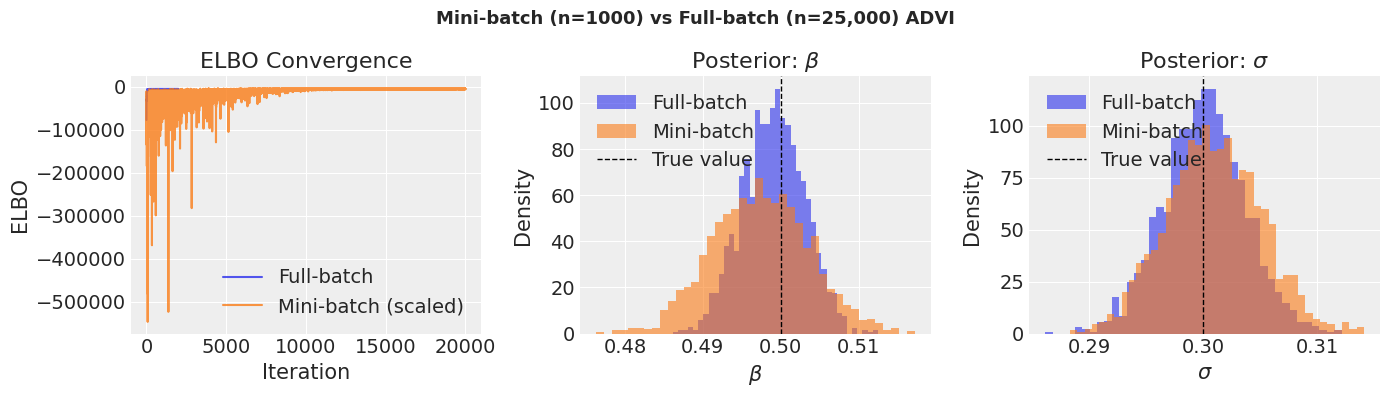

In [9]:
# Visual comparison: Mini-batch vs Full-batch ADVI
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# ELBO convergence (scaled to be comparable)
ax = axes[0]
elbo_full = -np.array(approx.hist)
elbo_mini = -np.array(approx_minibatch.hist) * (n_obs / 1000)  # Scale by n/batch_size

ax.plot(elbo_full, label='Full-batch', alpha=0.8)
ax.plot(elbo_mini, label='Mini-batch (scaled)', alpha=0.8)
# ax.set_ylim(-1e4, -5000 )
ax.set_xlabel('Iteration')
ax.set_ylabel('ELBO')
ax.set_title('ELBO Convergence')
ax.legend()

# Sample from both approximations
samples_full = approx.sample(2000)
samples_mini = approx_minibatch.sample(2000)

beta_full = samples_full.posterior['beta'].values.flatten()
beta_mini = samples_mini.posterior['beta'].values.flatten()
sigma_full = samples_full.posterior['sigma'].values.flatten()
sigma_mini = samples_mini.posterior['sigma'].values.flatten()

# Beta posterior comparison
ax = axes[1]
ax.hist(beta_full, bins=40, density=True, alpha=0.6, label='Full-batch')
ax.hist(beta_mini, bins=40, density=True, alpha=0.6, label='Mini-batch')
ax.axvline(true_beta, color='k', linestyle='--', lw=1, label='True value')
ax.set_xlabel(r'$\beta$')
ax.set_ylabel('Density')
ax.set_title(r'Posterior: $\beta$')
ax.legend()

# Sigma posterior comparison
ax = axes[2]
ax.hist(sigma_full, bins=40, density=True, alpha=0.6, label='Full-batch')
ax.hist(sigma_mini, bins=40, density=True, alpha=0.6, label='Mini-batch')
ax.axvline(true_sigma, color='k', linestyle='--', lw=1, label='True value')
ax.set_xlabel(r'$\sigma$')
ax.set_ylabel('Density')
ax.set_title(r'Posterior: $\sigma$')
ax.legend()

fig.suptitle(f'Mini-batch (n={1000}) vs Full-batch (n={n_obs:,}) ADVI', fontsize=13, fontweight='bold')
plt.tight_layout();

## VI Diagnostics
Generally harder than for MCMC. Little consensus on best approach.
### Check convergence
1. Check that the ELBO history flattens out. *It can be noisy; smoothing with a window of 100-300 will help.*
2. [sensitivity analysis] Check that the ELBO reaches the same level with multiple learning rates

### Check Approximation
1. Check posterior predictive distribution: can it generate points that look like observations
2. Check agreement with other inference methods. Is the mode in agreement with MAP, run short MCMC chains to check against.

The ELBO can only diagnose convergence failures (optimization got stuck), not approximation failures (the best $q$ in $Q$ is still bad). This is why we check them separately.

<br/><br/><br/><br/><br/><br/><br/><br/><br/><br/>

# Laplace Approximation ≠ Full-Rank ADVI

Both fit a multivariate Gaussian to the posterior, but they get there differently:

| | Laplace / QUAP | Full-Rank ADVI |
|---|---|---|
| **How it finds the mean** | MAP estimate (mode of the posterior) | Optimizes the ELBO (variational objective) |
| **How it finds the covariance** | Hessian of the log-posterior at the MAP | Learned directly as a Cholesky factor via gradient descent |
| **Assumption** | Posterior is well-approximated by a Gaussian *centered at the mode* | Best Gaussian in KL-divergence sense — mean can differ from the mode |
| **Failure mode** | Breaks down when the posterior is skewed, multimodal, or has constrained boundaries — the Hessian at the mode misrepresents the global shape | Can underestimate variance (KL(q‖p) is mode-seeking) but adapts the mean freely |
| **Cost** | One optimization + one Hessian computation: fast and deterministic | Iterative stochastic optimization: slower, needs tuning (learning rate, MC samples) |

### When they agree
Symmetric, unimodal posteriors with lots of data.

**Key intuition**: Laplace says *"find the peak, then measure curvature there."* Full-rank ADVI says *"find the best Gaussian overall, wherever it wants to sit."* When the posterior is asymmetric (e.g., `sigma ~ Exponential`), the mode and the mean of the best-fit Gaussian diverge: Laplace struggles and ADVI adapts (*but still may struggle*).

<br/><br/><br/><br/><br/><br/><br/><br/><br/><br/>

# SVGD: Stein Variational Gradient Descent
Changing gears, we now tackle minimizing the KL divergence head-on!

## Theoretical Foundations

### Stein's Identity
For a smooth density $p$ and a smooth vector-valued test function $\phi : \mathbb{R}^d \to \mathbb{R}^d$ vanishing at the boundary,
$$\forall \phi \in \Phi, \; \mathbb{E}_p\!\bigl[\mathcal{A}_p \phi(\theta)\bigr] = 0$$
where $$\mathcal{A}_p \phi(\theta) = \nabla_\theta \log p(\theta|\mathcal{D}) \cdot \phi(\theta) + \nabla_\theta \cdot \phi(\theta)$$
is the **Stein operator**.

If $\Phi$ is large enough, then the identity characterises $p$: if $\mathbb{E}_q[\mathcal{A}_p \phi] \neq 0$ for some $\phi$, then $q \neq p$.

**At home**: Show that if $p$ is differentiable and $\phi$ is differentiable and vanishes at the boundaries, then $\mathbb{E}_p\!\bigl[\mathcal{A}_p \phi(\theta)\bigr] = 0$. (Hint: recall $\nabla \log f = \frac{\nabla f}{f}$ and use integration by parts.)

### Kernelized Stein Discrepancy (KSD): Picking $\Phi$
Restrict $\phi$ to a reproducing kernel Hilbert space $\mathcal{H}$ with kernel $k$:
$$\text{KSD}(q, p) = \max_{\phi \in \mathcal{H},\; \|\phi\| \leq 1} \;\mathbb{E}_q\!\bigl[\mathcal{A}_p \phi(\theta)\bigr]$$

The maximiser $\phi^*$ can be computed in closed form because the kernel trick lets us evaluate inner products in the (possibly infinite-dimensional) RKHS via the kernel function $k$, giving the **optimal perturbation direction** for transporting $q$ towards $p$.


<br/><br/><br/><br/><br/><br/><br/><br/><br/><br/>

### Connection to KL Divergence
Consider a small perturbation of the identity map:
$$T(\theta) = \theta + \epsilon \, \phi(\theta)$$
where $\phi$ is the perturbation direction and $\epsilon$ controls the step size. Let $q_{[T]}$ denote the density of $T(\theta)$ when $\theta \sim q$.

The change of variables formula introduces a Jacobian determinant $\det(I + \epsilon\,\nabla_\theta \phi)$ that measures how $T$ stretches or compresses local volume. Differentiating at $\epsilon=0$ gives $\text{trace}(\nabla_\theta \phi) = \nabla_\theta \cdot \phi$, which is why the Stein operator's two terms have a geometric reading: $\nabla_\theta \log p \cdot \phi$ captures the change in log-density from moving particles, while $\nabla_\theta \cdot \phi$ captures the change in log-volume from deforming their neighborhood.

**Theorem (Liu & Wang, 2016):**
$$\nabla_\epsilon \text{KL}(q_{[T]} \| p)\big|_{\epsilon=0} = -\mathbb{E}_{q}\!\bigl[\mathcal{A}_p \phi(\theta)\bigr]$$

The derivative of the KL divergence under perturbation *is* the expected Stein operator — exactly the quantity KSD maximises!

Choosing $\phi^*$ from the RKHS unit ball gives the **steepest descent direction** on the KL divergence:
$$\phi^*_{q,p}(\cdot) = \mathbb{E}_{q}\!\bigl[k(\theta, \cdot)\,\nabla_\theta \log p(\theta) + \nabla_\theta k(\theta, \cdot)\bigr]$$

with the corresponding gradient:
$$\nabla_\epsilon \text{KL}(q_{[T]} \| p)\big|_{\epsilon=0} = -\text{KSD}(q, p)$$

This tells us that each SVGD step performs **functional gradient descent on the KL divergence** in RKHS.

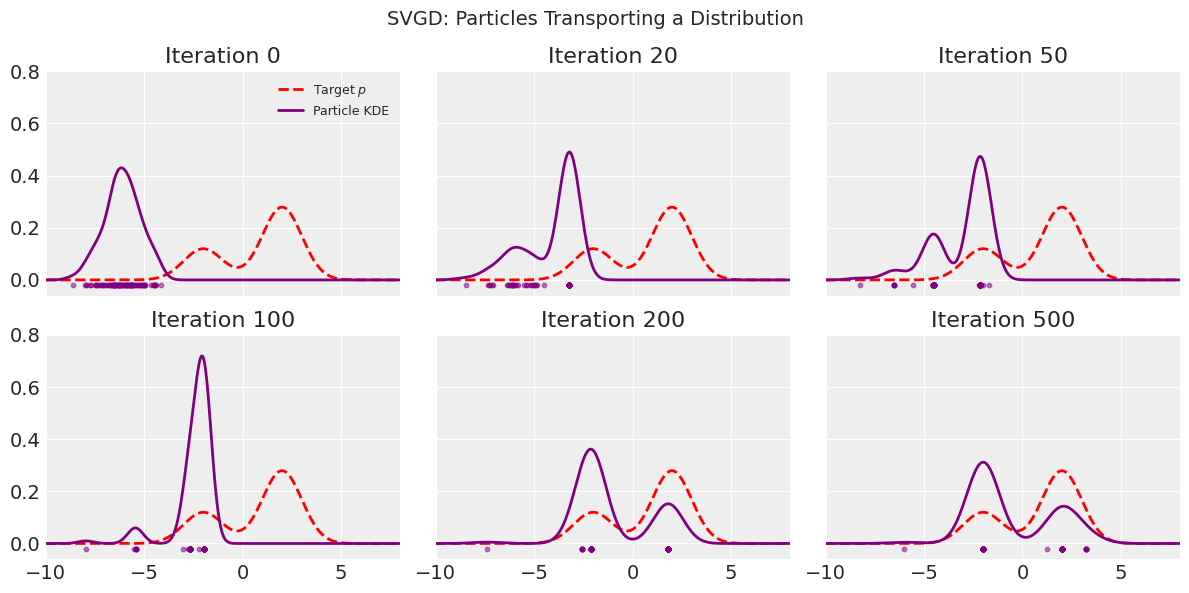

In [10]:
# Target: bimodal Gaussian mixture
def log_p(x):
    return np.log(0.3 * np.exp(-0.5 * (x + 2)**2) + 0.7 * np.exp(-0.5 * (x - 2)**2))

def grad_log_p(x):
    p1 = 0.3 * np.exp(-0.5 * (x + 2)**2)
    p2 = 0.7 * np.exp(-0.5 * (x - 2)**2)
    return (p1 * (-(x + 2)) + p2 * (-(x - 2))) / (p1 + p2)

# RBF kernel and its gradient
def rbf_kernel(x, h):
    diff = x[:, None] - x[None, :]
    K = np.exp(-diff**2 / (2 * h**2))
    dK = -diff / h**2 * K  # gradient w.r.t. first argument
    return K, dK

# SVGD update
def svgd_step(x, step_size):
    med = np.median(np.abs(x[:, None] - x[None, :]))
    h = med**2 / np.log(len(x) + 1)
    h = max(h, 1e-5)
    K, dK = rbf_kernel(x, np.sqrt(h))
    grad = grad_log_p(x)
    # attraction + repulsion
    phi = (K @ grad + dK.sum(axis=1)) / len(x)
    return x + step_size * phi

# Run SVGD and store snapshots
np.random.seed(42)
n_particles = 100
x = np.random.randn(n_particles) - 6  # initialise far from target

snapshots = [x.copy()]
snapshot_iters = [0, 20, 50, 100, 200, 500]
for i in range(1, 501):
    x = svgd_step(x, step_size=0.1)
    if i in snapshot_iters:
        snapshots.append(x.copy())

# Plot
t = np.linspace(-10, 8, 500)
target = np.exp(log_p(t))
target /= np.trapezoid(target, t)

fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharex=True, sharey=True)
for ax, particles, it in zip(axes.flatten(), snapshots, snapshot_iters):
    ax.plot(t, target, 'r--', lw=2, label='Target $p$')
    ax.scatter(particles, -0.02 * np.ones_like(particles),
               c='purple', s=10, alpha=0.5, zorder=5)
    if len(np.unique(particles)) > 2:
        kde = gaussian_kde(particles)
        ax.plot(t, kde(t), 'purple', lw=2, label='Particle KDE')
    ax.set_title(f'Iteration {it}')
    ax.set_ylim(-0.06, 0.8)
    ax.set_xlim(-10, 8)

axes[0, 0].legend(fontsize=9)
fig.suptitle('SVGD: Particles Transporting a Distribution', fontsize=14)
plt.tight_layout()

<br/><br/><br/><br/><br/><br/><br/><br/><br/><br/>

## SVGD Update Rule

Given $n$ particles $\{x_i\}_{i=1}^n$ approximating $q$, update:

$$x_i^{(l+1)} \leftarrow x_i^{(l)} + \epsilon_l \,\hat{\phi}^*(x_i^{(l)})$$

where the empirical optimal perturbation is:

$$\hat{\phi}^*(x) = \frac{1}{n}\sum_{j=1}^{n} \Bigl[
  \underbrace{k(x_j, x)\,\nabla_{x_j}\!\log p(x_j)}_{\text{attraction: move toward high-density}}
  \;+\;
  \underbrace{\nabla_{x_j}\!k(x_j, x)}_{\text{repulsion: spread particles apart}}
\Bigr]$$

**Key insight:** Without the repulsion term, all particles converge to the mode (like MAP). The kernel gradient acts as an entropy regularizer that prevents collapse.

**Common kernel:** RBF kernel $k(x, x') = \exp\!\bigl(-\|x - x'\|^2 / (2h^2)\bigr)$, where bandwidth $h$ is often set by the median heuristic.

$h$ is chosen adaptively by the median heuristic: $h = \frac{\text{med}^2}{\log n}$, where $\text{med}$ is the median pairwise distance.

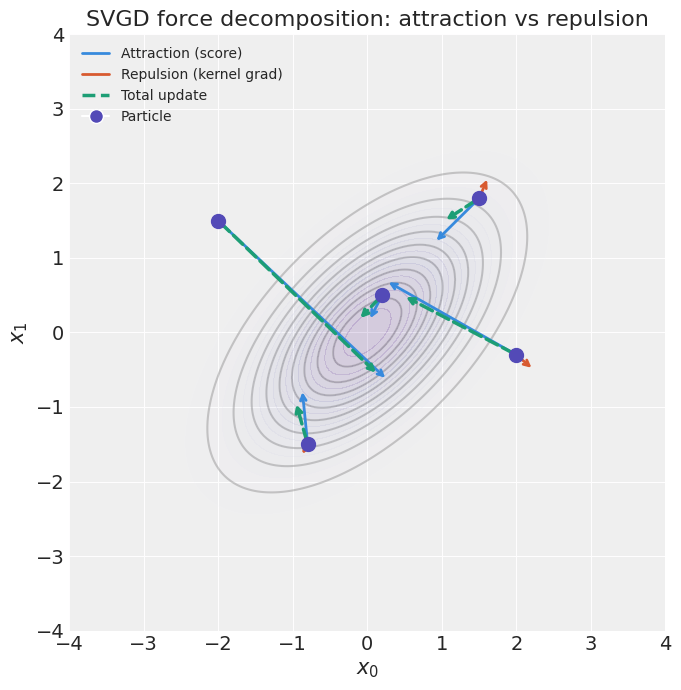

In [11]:

mu = np.array([0.0, 0.0])
Sigma = np.array([[1.0, 0.6],
                   [0.6, 1.0]])
Sigma_inv = np.linalg.inv(Sigma)

def grad_log_p(x):
    """Gradient of log p(x) for a 2D Gaussian (vectorized over particles)."""
    return -np.einsum('ij,...j->...i', Sigma_inv, x - mu)

particles = np.array([
    [-2.0,  1.5],
    [ 1.5,  1.8],
    [-0.8, -1.5],
    [ 2.0, -0.3],
    [ 0.2,  0.5],
])

h = median_bandwidth(particles)
h = max(h, 0.1)  # floor for numerical stability
attractions, repulsions, _ = svgd_forces(particles, grad_log_p, h)
totals = attractions + repulsions

fig, ax = plt.subplots(figsize=(7, 7))

# Contours of target density
grid = np.linspace(-4, 4, 200)
X, Y = np.meshgrid(grid, grid)
pos = np.stack([X, Y], axis=-1)
diff = pos - mu
Z = np.exp(-0.5 * np.einsum('...i,ij,...j', diff, Sigma_inv, diff))
ax.contour(X, Y, Z, levels=10, colors='gray', alpha=0.4)
ax.contourf(X, Y, Z, levels=20, cmap='Purples', alpha=0.15)

# Scale arrows for visibility
scale = 2.5

for i, (px, py) in enumerate(particles):
    # Particle dot
    ax.plot(px, py, 'o', color='#534AB7', markersize=10, zorder=5)

    # Attraction (blue)
    ax.annotate('', xy=(px + scale*attractions[i,0], py + scale*attractions[i,1]),
                xytext=(px, py),
                arrowprops=dict(arrowstyle='->', color='#378ADD', lw=2.0))
    # Repulsion (coral)
    ax.annotate('', xy=(px + scale*repulsions[i,0], py + scale*repulsions[i,1]),
                xytext=(px, py),
                arrowprops=dict(arrowstyle='->', color='#D85A30', lw=2.0))
    # Total (green)
    ax.annotate('', xy=(px + scale*totals[i,0], py + scale*totals[i,1]),
                xytext=(px, py),
                arrowprops=dict(arrowstyle='->', color='#1D9E75', lw=2.5, linestyle='--'))

legend_elements = [
    Line2D([0], [0], color='#378ADD', lw=2, label='Attraction (score)'),
    Line2D([0], [0], color='#D85A30', lw=2, label='Repulsion (kernel grad)'),
    Line2D([0], [0], color='#1D9E75', lw=2.5, linestyle='--', label='Total update'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#534AB7',
           markersize=10, label='Particle'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=10)

ax.set_xlim(-4, 4); ax.set_ylim(-4, 4)
ax.set_xlabel(r'$x_0$'); ax.set_ylabel(r'$x_1$')
ax.set_title('SVGD force decomposition: attraction vs repulsion')
ax.set_aspect('equal')
plt.tight_layout()

<br/><br/><br/><br/><br/><br/><br/><br/><br/><br/>

## When SVGD Struggles

| Issue | Root Cause | Consequence |
|-------|-----------|-------------|
| **High dimensions** | Particles are sparse in $\mathbb{R}^d$ for large $d$ | Gradient variance increases; slow convergence |
| **Kernel bandwidth** | Median heuristic may be suboptimal | Under-exploration or mode collapse |
| **Computational cost** | $O(n^2 d)$ per iteration (kernel matrix) | Limits practical particle count |
| **No formal diagnostics** | Unlike MCMC (ESS, $\hat{R}$), no established diagnostics for finite $n$ | Hard to know when to stop (Stein force as surrogate) |

<br/><br/><br/><br/><br/><br/><br/><br/><br/><br/>

# Summary: Inference as Geometric Projection

With the KL divergence and ELBO in hand, we can view VI methods as solving:

$$q^* = \arg\min_{q \in \mathcal{Q}} \;\mathrm{KL}(q \,\|\, p(\theta \mid \mathcal{D}))$$

For methods like MAP and ADVI, this is equivalent to maximising the ELBO. **Note:** SVGD minimises the KL divergence directly via functional gradient descent — it does not optimise the ELBO.

Recall: the family $\mathcal{Q}$ is the **constraint set**. Different choices of $\mathcal{Q}$ yield different methods:

| Method | Family $\mathcal{Q}$ | Dimension of optimisation |
|--------|----------------------|--------------------------|
| MAP | $\{\delta_{\theta^*} : \theta^* \in \Theta\}$ | $d$ (point in parameter space) |
| Mean-field ADVI | $\prod_{i=1}^{d} \mathcal{N}(\mu_i, \sigma_i^2)$ | $2d$ |
| Full-rank ADVI | $\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$ | $d + d(d{+}1)/2$ |
| SVGD | $\frac{1}{n}\sum_{i=1}^{n}\delta_{\theta_i}$ | $nd$ |
| MCMC | —  | — |

**Terminology note:** We use "projection" in the geometric sense here. In abstract algebra, a projection $P$ satisfies $P(P(x)) = P(x)$ (idempotence). Our usage is the geometric intuition: we find the closest point in $\mathcal{Q}$ to the true posterior under KL divergence (if it is idempotent and unique then the minimizer is actually an algebraic projection as well).

> **Key insight:** A method that cannot *represent* a posterior feature will not *find* it.
> This is a structural limitation, not a convergence failure.

<br/><br/><br/><br/><br/><br/><br/><br/><br/><br/>

# Two Pathological Examples

We will look at two canonical examples, each with its own pathology. Together they illustrate the two fundamental geometric obstacles for variational inference:  **global curvature**, and **topology**.

# Failure Mode 1: Rosenbrock Likelihood — Position-Dependent Global Curvature

$$\log p(x_0, x_1) = -(1 - x_0)^2 - b(x_1 - x_0^2)^2$$

The conditional mean $\mathbb{E}[x_1 \mid x_0] = x_0^2$ is **quadratic** in $x_0$. The Hessian matrix depends on position:

$$-\nabla^2 \log p = \begin{pmatrix} 2 + 4b x_0^2 + 4b(x_1 - x_0^2) & -4b x_0 \\ -4b x_0 & 2b \end{pmatrix}$$

The off-diagonal terms and the $(1,1)$ entry are functions of $(x_0, x_1)$.

**Why it matters:** The posterior has non-constant curvature, that is it *bends*. Any Gaussian approximation (including full-rank ADVI) uses a single fixed covariance matrix $\Sigma$, which corresponds to constant curvature everywhere. The Rosenbrock's banana shape cannot be captured by any ellipse. This is a *global* geometry problem, the issue is the overall shape, not just local scaling.

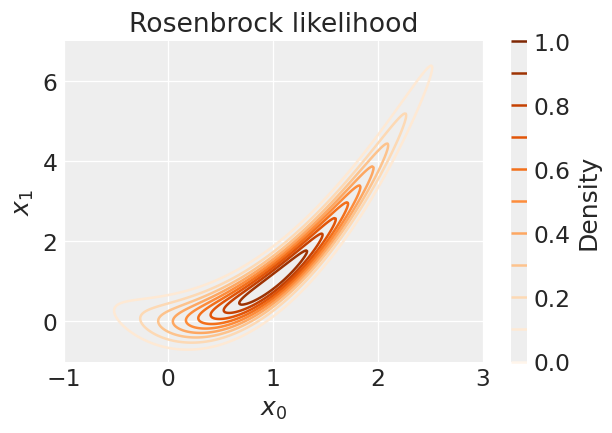

In [12]:

fig, ax = plt.subplots(figsize=(5, 3.5), dpi=120, constrained_layout=True)
X0, X1 = np.meshgrid(np.linspace(-1, 3, 300), np.linspace(-1, 7, 300))
ax.contour(X0, X1, np.exp(rosenbrock_logp(X0, X1)), levels=10, cmap='Oranges')
plt.colorbar(ax.collections[0], label='Density')
ax.set(xlabel=r'$x_0$', ylabel=r'$x_1$', title='Rosenbrock likelihood');



In [13]:
# We are really approximating a distribution here, not doing inference, because there is not observation.

with pm.Model() as rosenbrock_model:
    x0 = pm.Normal('x0', mu=0, sigma=2)
    x1 = pm.Normal('x1', mu=0, sigma=2)
    pm.Potential('rosenbrock', rosenbrock_logp_pt(x0, x1))

with rosenbrock_model:
    # MAP
    map_rosenbrock = pm.find_MAP()

    # MCMC
    trace_rosenbrock = pm.sample(4000, progressbar=False)

    # ADVI (full-rank)
    approx_rosenbrock = pm.fit(method='fullrank_advi', n=20_000, progressbar=False,
                                obj_optimizer=adam(learning_rate=0.01))
    trace_advi_rosenbrock = approx_rosenbrock.sample(2000)

    # SVGD
    svgd_rosenbrock = pm.fit(method='svgd', n=5_000, progressbar=False,
                              obj_optimizer=adam(learning_rate=0.1))
    trace_svgd_rosenbrock = svgd_rosenbrock.sample(2000);

Output()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [x0, x1]
Sampling 4 chains for 1_000 tune and 4_000 draw iterations (4_000 + 16_000 draws total) took 12 seconds.
There were 28 divergences after tuning. Increase `target_accept` or reparameterize.
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
Finished [100%]: Average Loss = 3.3508


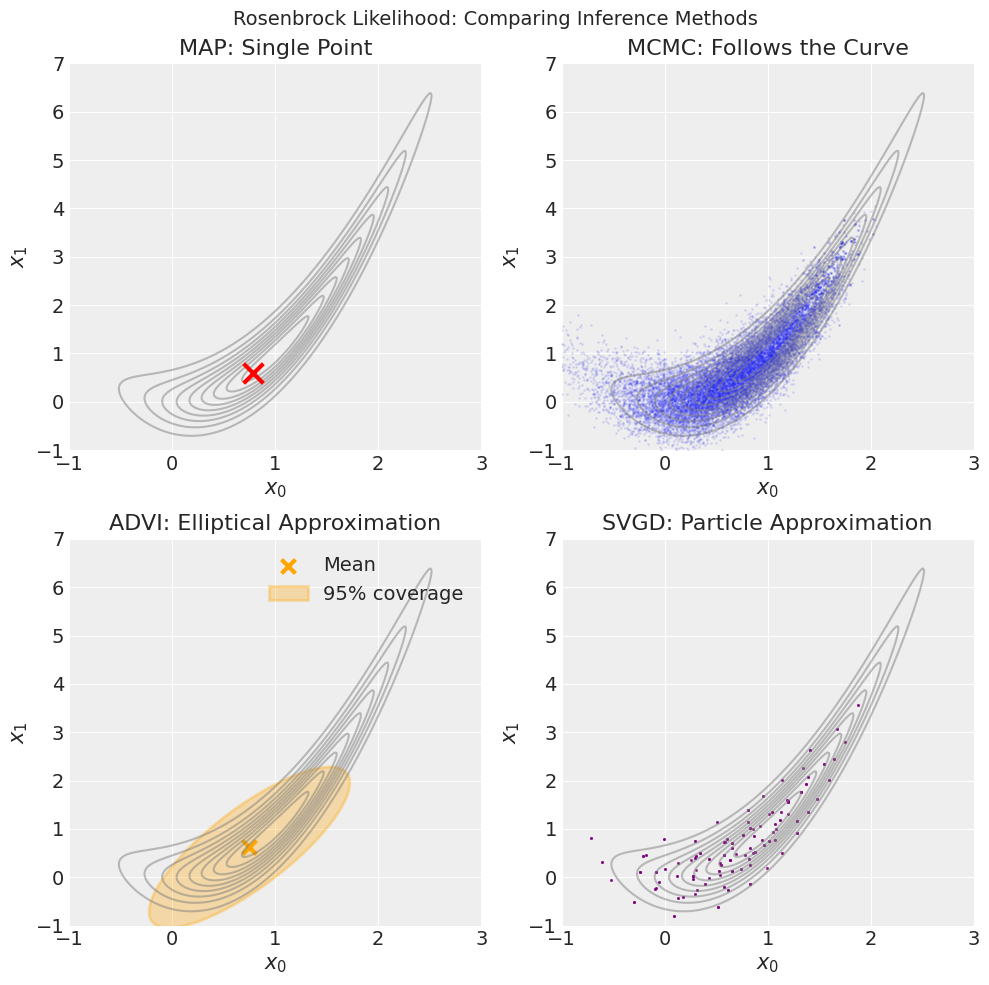

In [14]:
X0, X1 = np.meshgrid(np.linspace(-1, 3, 300), np.linspace(-1, 7, 300))
rosenbrock_density = np.exp(rosenbrock_logp(X0, X1))

# Get mean and covariance from ADVI approximation
advi_mean_rosenbrock = approx_rosenbrock.mean.eval()
advi_cov_rosenbrock = approx_rosenbrock.cov.eval()

# Compute 95% confidence ellipse parameters
eigenvalues_r, eigenvectors_r = np.linalg.eigh(advi_cov_rosenbrock)
angle_r = np.degrees(np.arctan2(eigenvectors_r[1, 1], eigenvectors_r[0, 1]))
chi2_val = 5.991  # 95% confidence for 2 dof
height_r, width_r = 2 * np.sqrt(chi2_val * eigenvalues_r)

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()

for ax in axes:
    ax.contour(X0, X1, rosenbrock_density, levels=10, colors='gray', alpha=0.5)
    ax.set_xlabel(r'$x_0$'); ax.set_ylabel(r'$x_1$')
    ax.set_xlim(-1, 3); ax.set_ylim(-1, 7)

# MAP
axes[0].scatter(map_rosenbrock['x0'], map_rosenbrock['x1'],
                color='red', s=200, marker='x', linewidths=3, zorder=5)
axes[0].set_title('MAP: Single Point')

# MCMC
axes[1].scatter(trace_rosenbrock.posterior['x0'].values.flatten(),
                trace_rosenbrock.posterior['x1'].values.flatten(),
                alpha=0.1, s=1)
axes[1].set_title('MCMC: Follows the Curve')

# ADVI (mean + 95% ellipse)
axes[2].scatter(advi_mean_rosenbrock[0], advi_mean_rosenbrock[1],
                color='orange', s=100, marker='x', linewidths=3, label='Mean')
ellipse_r = Ellipse(xy=advi_mean_rosenbrock, width=width_r, height=height_r, angle=angle_r,
                    edgecolor='orange', facecolor='orange', alpha=0.3, linewidth=2, label='95% coverage')
axes[2].add_patch(ellipse_r)
axes[2].set_title('ADVI: Elliptical Approximation')
axes[2].legend()

# SVGD
axes[3].scatter(trace_svgd_rosenbrock.posterior['x0'].values.flatten(),
                trace_svgd_rosenbrock.posterior['x1'].values.flatten(),
                alpha=0.1, s=1, color='purple')
axes[3].set_title('SVGD: Particle Approximation')

fig.suptitle('Rosenbrock Likelihood: Comparing Inference Methods', fontsize=14)
plt.tight_layout()

<br/><br/><br/><br/><br/><br/><br/><br/><br/><br/>

# Failure Mode 2: Two Beans — Topological Obstruction

$$\log p(x_0, x_1) = -\frac{1}{2}\left(\frac{\lVert x \rVert - 3}{0.4}\right)^2 + \log\left(e^{-\frac{(x_0 - 3)^2}{2 \cdot 0.4^2}} + e^{-\frac{(x_0 + 3)^2}{2 \cdot 0.4^2}}\right)$$

The first term concentrates mass on a shell (technically an annulus) of radius 3. The second term selects two arcs at $x_0 \approx \pm 3$. The result is **two disconnected crescent-shaped modes**.

**Why it matters:** The support of $p$ has two connected components. A unimodal family $\mathcal{Q}$ (point mass, Gaussian) is topologically connected — it cannot represent disconnected support *regardless of optimisation quality*. This is a *topological* obstruction: the approximating family lacks the representational capacity to capture multimodality. No amount of tuning or convergence can fix this.


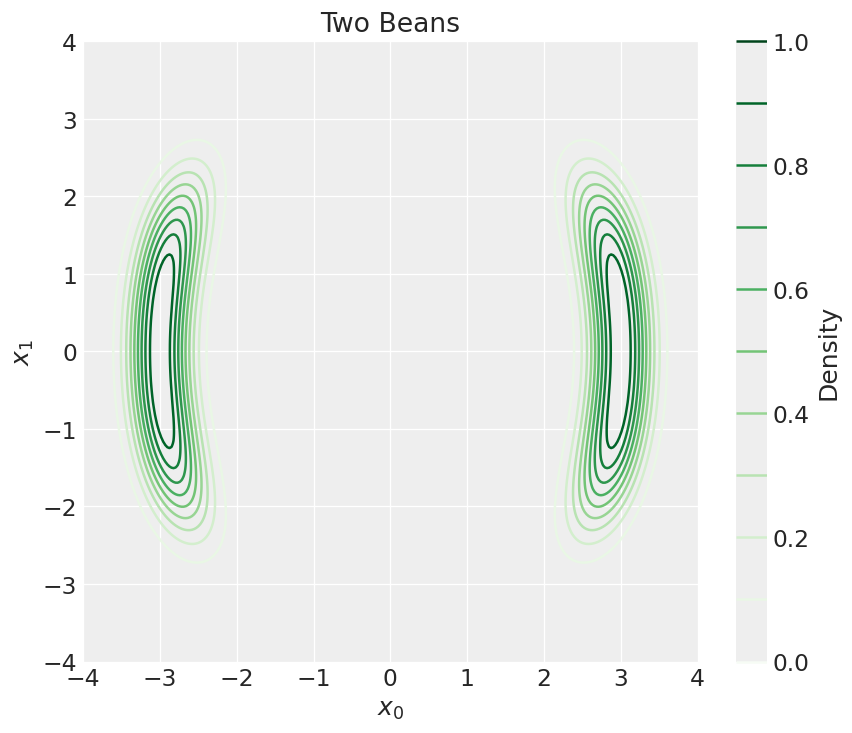

In [15]:
fig, ax = plt.subplots(figsize=(7, 6), dpi=120, constrained_layout=True)
X0, X1 = np.meshgrid(np.linspace(-4, 4, 300), np.linspace(-4, 4, 300))
logp_values = two_beans_logp(X0, X1)
ax.contour(X0, X1, np.exp(logp_values), levels=10, cmap='Greens')
plt.colorbar(ax.collections[0], label='Density')
ax.set(xlabel=r'$x_0$', ylabel=r'$x_1$', title='Two Beans');

## A Topological Obstruction

**Log density:** (same as defined earlier)
$$\log p(x_0, x_1) = -\frac{1}{2}\left(\frac{\lVert x \rVert - 3}{0.4}\right)^2 + \log\left(e^{-\frac{(x_0 - 3)^2}{2 \cdot 0.4^2}} + e^{-\frac{(x_0 + 3)^2}{2 \cdot 0.4^2}}\right)$$

**Structure:**
- The first term concentrates mass on an **annulus** of radius $\approx 3$.
- The logsumexp creates two **crescent-shaped modes** centred at $x_0 = \pm 3$.
- The modes are separated by a region of near-zero density.

**Why this defeats VI:**

The support of $p$ has two **connected components**. A unimodal family $\mathcal{Q}$ (Gaussian, point mass) is connected and simply cannot represent disconnected support.

- **MAP:** Returns one mode only.
- **ADVI (any rank):** Places a single Gaussian that must either pick one mode or straddle both, wasting mass in the empty valley.
- **MCMC:** Each chain gets trapped in one mode.
- **SVGD:** Can potentially capture both modes if enough particles are initialised in both basins.

In [16]:
with pm.Model() as two_beans_model:
    x = pm.Normal('x', mu=0, sigma=2, shape=2)
    pm.Potential('two_beans', two_beans_logp_pt(x))

In [17]:
with two_beans_model:
    # MAP
    map_beans = pm.find_MAP(start={'x': np.array([1,0])})

    # MCMC
    trace_beans = pm.sample(4000, chains=4, random_seed=10, progressbar=False)

    # ADVI (full-rank)
    approx_beans = pm.fit(method='fullrank_advi', n=20_000, progressbar=False,
                          obj_optimizer=adam(learning_rate=0.005), obj_n_mc=30)

    # SVGD
    svgd_beans = pm.fit(method='svgd', n=5_000, progressbar=False,
                        obj_optimizer=adam(learning_rate=0.1))

Output()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [x]
Sampling 4 chains for 1_000 tune and 4_000 draw iterations (4_000 + 16_000 draws total) took 21 seconds.
There were 4 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
Finished [100%]: Average Loss = 16.451


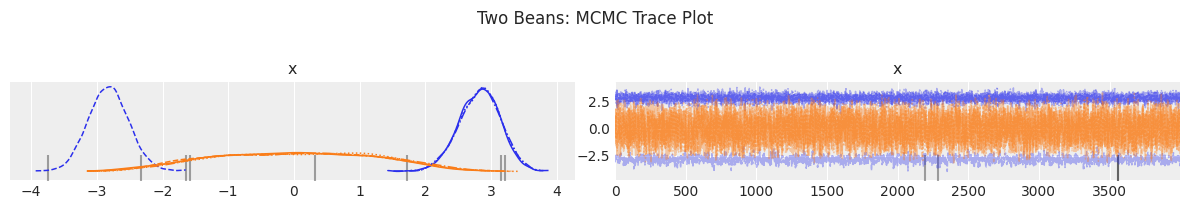

In [18]:
az.plot_trace(trace_beans, var_names=['x'])
plt.suptitle('Two Beans: MCMC Trace Plot', y=1.02)
plt.tight_layout()

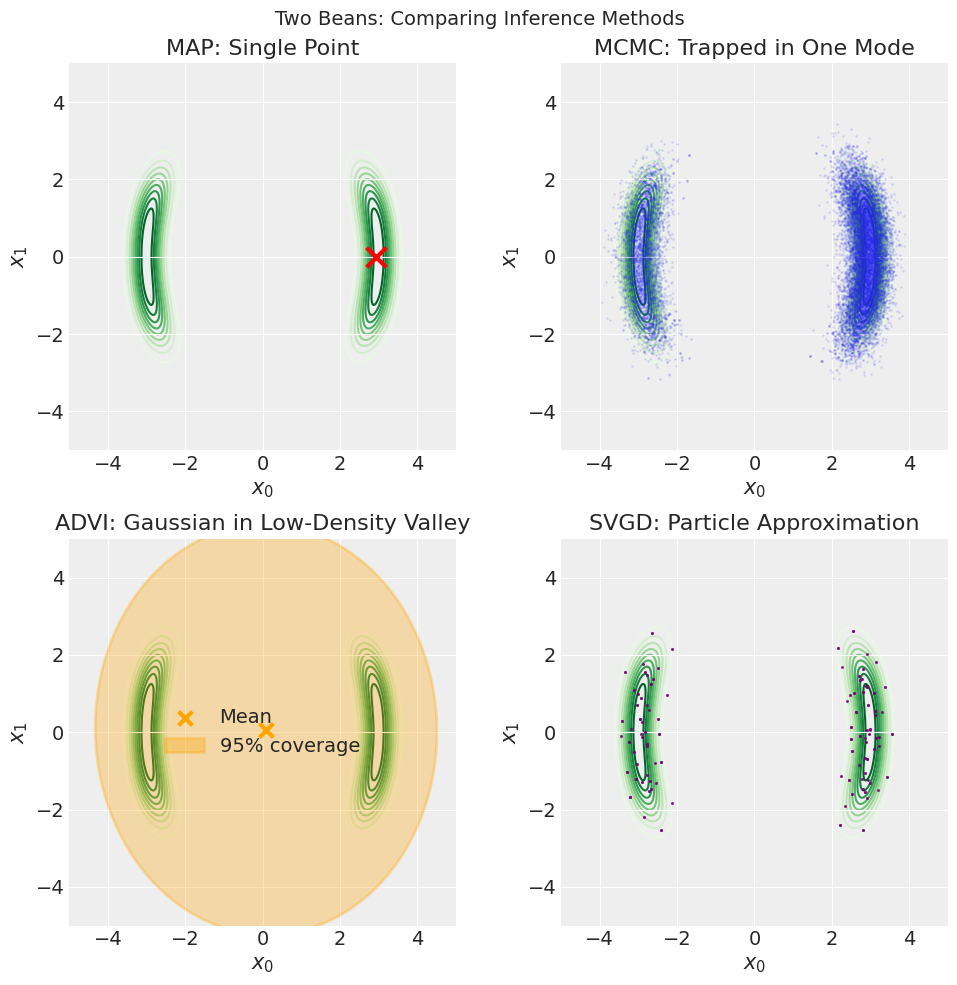

In [19]:
# Get mean and covariance from ADVI approximation
advi_mean = approx_beans.mean.eval()
advi_cov = approx_beans.cov.eval()

# Compute 95% confidence ellipse parameters
eigenvalues, eigenvectors = np.linalg.eigh(advi_cov)
angle = np.degrees(np.arctan2(eigenvectors[1, 1], eigenvectors[0, 1]))
chi2_val = chi2.ppf(0.95, df=2) # 95% confidence for 2 dof
width, height = 2 * np.sqrt(chi2_val * eigenvalues)

# Get SVGD samples
trace_svgd_beans = svgd_beans.sample(2000)

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()

for ax in axes:
    ax.contour(X0, X1, np.exp(logp_values), levels=10, cmap='Greens', zorder=0)
    ax.set_xlabel(r'$x_0$'); ax.set_ylabel(r'$x_1$')
    ax.set_aspect('equal')
    ax.set_xlim(-5, 5); ax.set_ylim(-5, 5)

# MAP
axes[0].scatter(map_beans['x'][0], map_beans['x'][1],
                color='red', s=200, marker='x', linewidths=3, zorder=5)
axes[0].set_title('MAP: Single Point')

# MCMC
x_mcmc = trace_beans.posterior['x'].values.reshape(-1, 2)
axes[1].scatter(x_mcmc[:, 0], x_mcmc[:, 1], alpha=0.1, s=1)
axes[1].set_title('MCMC: Trapped in One Mode')

# ADVI (mean + 95% ellipse)
axes[2].scatter(advi_mean[0], advi_mean[1], color='orange', s=100, marker='x', linewidths=3, label='Mean')
ellipse = Ellipse(xy=advi_mean, width=width, height=height, angle=angle,
                  edgecolor='orange', facecolor='orange', alpha=0.3, linewidth=2, label='95% coverage')
axes[2].add_patch(ellipse)
axes[2].set_title('ADVI: Gaussian in Low-Density Valley')
axes[2].legend()

# SVGD
x_svgd = trace_svgd_beans.posterior['x'].values.reshape(-1, 2)
axes[3].scatter(x_svgd[:, 0], x_svgd[:, 1], alpha=0.1, s=1, color='purple')
axes[3].set_title('SVGD: Particle Approximation')

fig.suptitle('Two Beans: Comparing Inference Methods', fontsize=14)
plt.tight_layout()

<br/><br/><br/><br/><br/><br/><br/><br/><br/><br/>

# Summary

## Inference Methods: Comparative Analysis

| Property | MAP | MF ADVI | FR ADVI | SVGD | MCMC (NUTS) |
|----------|-----|---------|---------|------|-------------|
| **Family $\mathcal{Q}$** | $\delta_{\theta^*}$ | $\prod_i \mathcal{N}(\mu_i, \sigma_i^2)$ | $\mathcal{N}(\mu, \Sigma)$ | $\frac{1}{n}\sum_i \delta_{\theta_i}$ | — |
| **Free parameters** | $d$ | $2d$ | $d + d(d{+}1)/2$ | $nd$ | — |
| **Per-step cost** | $O(d)$ | $O(d)$ | $O(d^2)$ | $O(n^2 d)$ | $O(dL)$ |
| **Uncertainty** | None | Marginal var. | Full cov. | Particle approx. | Exact (asymp.) |
| **Correlations** | ✗ | ✗ | ✓ (Gaussian) | ✓ | ✓ |
| **Multimodality** | ✗ | ✗ | ✗ | ✓ (if $n$ sufficient) | Requires mixing |

## When Methods Fail: Root-Cause Summary

| Geometry | Mathematical Root Cause | MAP | MF ADVI | FR ADVI | SVGD | MCMC |
|----------|------------------------|-----|---------|---------|------|------|
| **Rosenbrock** | Quadratic conditional mean: $\mathbb{E}[x_1 \mid x_0] = x_0^2$ | Single point | Axis-aligned ellipse | Ellipse (not curve) | Follows curve | Correct |
| **Two Beans** | Disconnected support: topological obstruction | One mode | Mass in valley | Mass in valley | Both modes (tuned) | Stuck in one mode |

<br/><br/><br/><br/><br/><br/><br/><br/><br/><br/>

## Selecting an Inference Method

**Decision tree:**

1. **Do you need uncertainty?**
   - No → MAP (fast, simple).
   - Yes → continue.

2. **Is the posterior approximately Gaussian?**
   - Yes, and $d$ is small → Full-rank ADVI or MCMC.
   - Yes, and $d$ is large → Mean-field ADVI (with posterior predictive checks).
   - No → continue.

3. **Is the posterior unimodal but non-Gaussian?**
   - Try MCMC (with reparameterization ((you'll learn about this)) if needed).
   - If too slow, try MAP or ADVI as an initialiser for MCMC.

4. **Is the posterior multimodal?**
   - SVGD (with enough particles) or parallel tempered MCMC.
   - Neither method guarantees mixing — be cautious.

5. **Always validate:** Run posterior predictive checks. Compare to a short MCMC run if feasible.

## Key Takeaway: Inference as Projection

$$q^* = \arg\min_{q \,\in\, \mathcal{Q}} \; \mathrm{KL}(q \,\|\, p(\theta \mid \mathcal{D}))$$

Every approximate inference method projects the true posterior onto $\mathcal{Q}$. What is preserved and what is lost depends entirely on the geometry of $\mathcal{Q}$:

| Method | Projects onto | Preserved | Lost |
|--------|---------------|-----------|------|
| MAP | Point masses | Mode location | All uncertainty |
| MF ADVI | Product of Gaussians | Marginal means & variances | Correlations, shape |
| FR ADVI | Single Gaussian | First two moments | Non-Gaussian features |
| SVGD | Particle cloud | Multimodality (discrete) | Continuous density |
| MCMC | — | Everything (asymptotically) | Finite-sample noise |

> **The choice of inference method determines which posterior features are visible.**
> A method that cannot represent a feature will not find it.